In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
# Step 1: Load the dataset (replace with correct path)
# KDD Cup 1999 dataset is available from various sources, including the UCI ML Repository.
# Assuming the dataset is loaded into 'data' DataFrame
data = pd.read_csv("kddcup.data", header=None)

# Step 2: Preprocess the dataset
# Assuming that last column is the target, and that categorical features need encoding
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
                'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 
                'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
                'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 
                'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
                'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
                'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

data.columns = column_names

In [3]:
data.shape

(4898431, 42)

In [4]:
data.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


In [5]:
# Convert categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, columns=['protocol_type', 'service', 'flag'])

# Step 3: Handle class imbalance and preprocess the data
# Label encoding for the target variable
data['label'] = data['label'].apply(lambda x: 1 if x == 'normal.' else 0)  # 1 for normal, 0 for attack

# Split into features (X) and target (y)
X = data.drop(columns=['label'])
y = data['label']

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# Step 4: Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [7]:
# Reshape data to match the RNN input format: (samples, time_steps, features)
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)

In [8]:
# Step 5: Build the RNN model
model = Sequential()

# Add a simple RNN layer
model.add(SimpleRNN(units=64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dropout(0.2))

# Add a Dense output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Step 7: Evaluate the model on the test set
y_pred = (model.predict(X_test) > 0.5).astype('int32')

# Step 8: Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 141s 1ms/step - accuracy: 0.9990 - loss: 0.0059 - val_accuracy: 0.9998 - val_loss: 0.0027
Epoch 2/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 135s 1ms/step - accuracy: 0.9997 - loss: 0.0042 - val_accuracy: 0.9996 - val_loss: 0.0026
Epoch 3/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 135s 1ms/step - accuracy: 0.9997 - loss: 0.0039 - val_accuracy: 0.9998 - val_loss: 0.0018
Epoch 4/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 133s 1ms/step - accuracy: 0.9997 - loss: 0.0046 - val_accuracy: 0.9998 - val_loss: 0.0026
Epoch 5/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 134s 1ms/step - accuracy: 0.9997 - loss: 0.0048 - val_accuracy: 0.9998 - val_loss: 0.0031
Epoch 6/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 134s 1ms/step - accuracy: 0.9997 - loss: 0.0054 - val_accuracy: 0.9997 - val_loss: 0.0032
Epoch 7/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 134s 1ms/step - accuracy: 0.9997 - loss: 0.0058 - val_accuracy: 0.9997 - val_loss: 0.0032
Epoch 8/10
107154/107154 ━━━━━━━━━━━━━━━━━━━━ 13

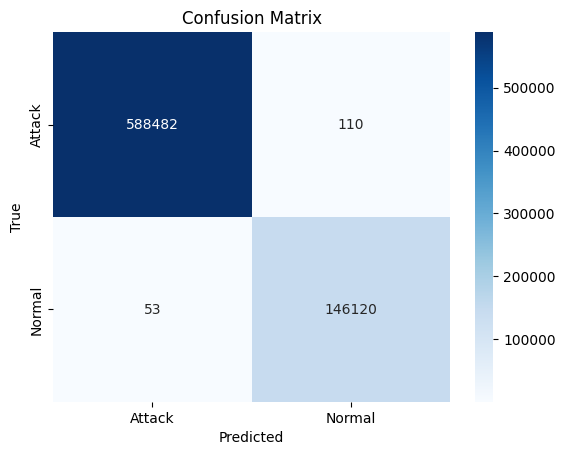

In [9]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

22962/22962 ━━━━━━━━━━━━━━━━━━━━ 14s 590us/step


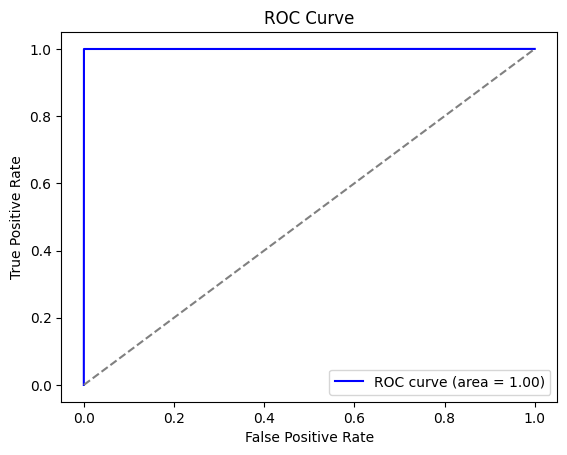

In [10]:
# Step 10: ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

22962/22962 ━━━━━━━━━━━━━━━━━━━━ 13s 546us/step


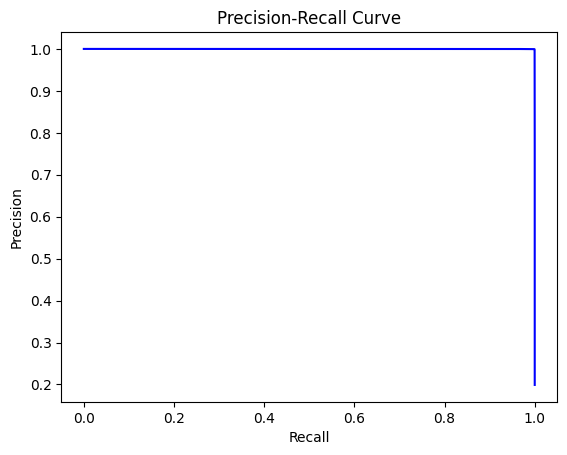

In [11]:
# Step 11: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, model.predict(X_test))
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()